In [1]:
import json
import pandas as pd

# 1. 파일 경로 설정
file_path = '../SSU_Datathon2025_공학분야_62199.json'

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    if "NODE_LIST" in data:
        df = pd.DataFrame(data["NODE_LIST"])

        if 'KYWD' in df.columns:
            # -------------------------------------------------------------
            # [핵심 로직] 키워드 개수 세기 함수
            # -------------------------------------------------------------
            def count_keywords(text):
                # 1) 데이터가 없거나(NaN) 빈 문자열("")인 경우 0개
                if pd.isna(text) or str(text).strip() == "":
                    return 0
                
                # 2) 쉼표(,)를 기준으로 나누기
                #    예: "Robot control, robot manipulators" -> ["Robot control", " robot manipulators"]
                tokens = text.split(',')
                
                # 3) 앞뒤 공백 제거 후 빈 값은 제외 (혹시 모를 ,, 같은 오타 방지)
                valid_keywords = [t.strip() for t in tokens if t.strip()]
                
                return len(valid_keywords)

            # 2. 'kywd_count' 컬럼 생성 (각 논문별 키워드 개수)
            df['kywd_count'] = df['KYWD'].apply(count_keywords)

            # 3. 개수별 논문 수 집계 (키워드 수 기준으로 정렬)
            result = df['kywd_count'].value_counts().sort_index()

            # 4. 결과 출력
            print("--- [분석] 키워드 개수별 논문 분포 ---")
            print(f"{'키워드 수':<10} | {'논문 편수':<10}")
            print("-" * 25)
            
            for k_cnt, p_cnt in result.items():
                print(f"{k_cnt:<10} | {p_cnt:<10}")

            # (참고) 통계 요약
            print("-" * 25)
            print(f"가장 많은 키워드 개수: {df['kywd_count'].max()}개")
            print(f"평균 키워드 개수: {df['kywd_count'].mean():.2f}개")

        else:
            print("KYWD 컬럼이 없습니다.")
    else:
        print("NODE_LIST 키가 없습니다.")

except Exception as e:
    print(f"에러 발생: {e}")

--- [분석] 키워드 개수별 논문 분포 ---
키워드 수      | 논문 편수     
-------------------------
0          | 16411     
1          | 10        
2          | 141       
3          | 2277      
4          | 7660      
5          | 16522     
6          | 4798      
7          | 1569      
8          | 3624      
9          | 1209      
10         | 6435      
11         | 276       
12         | 901       
13         | 54        
14         | 188       
15         | 25        
16         | 66        
17         | 8         
18         | 7         
19         | 2         
20         | 10        
21         | 2         
22         | 1         
23         | 1         
24         | 1         
28         | 1         
-------------------------
가장 많은 키워드 개수: 28개
평균 키워드 개수: 4.56개


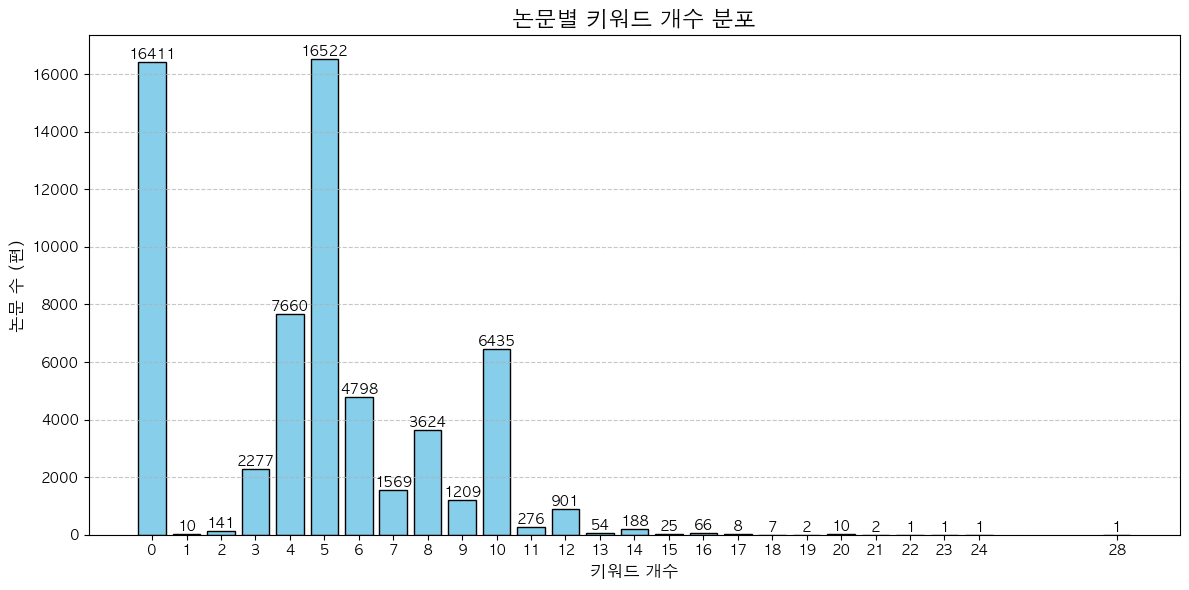

In [2]:
# 그래프로 시각화

import json
import pandas as pd
import matplotlib.pyplot as plt
import platform

# 1. 파일 경로 설정 (본인 경로에 맞게 수정)
file_path = '../SSU_Datathon2025_공학분야_62199.json'

try:
    # --- 데이터 로드 및 전처리 ---
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    if "NODE_LIST" in data:
        df = pd.DataFrame(data["NODE_LIST"])

        if 'KYWD' in df.columns:
            # 키워드 개수 계산 함수
            def count_keywords(text):
                if pd.isna(text) or str(text).strip() == "":
                    return 0
                tokens = text.split(',')
                # 공백 제거 후 유효한 단어만 카운트
                valid_keywords = [t.strip() for t in tokens if t.strip()]
                return len(valid_keywords)

            df['kywd_count'] = df['KYWD'].apply(count_keywords)

            # 개수별 논문 수 집계 (인덱스 정렬: 0개, 1개, 2개... 순서)
            count_data = df['kywd_count'].value_counts().sort_index()

            # --- 시각화 (Bar Graph) ---
            plt.figure(figsize=(12, 6))

            # 한글 폰트 설정 (OS에 맞게 자동 설정)
            system_name = platform.system()
            if system_name == 'Darwin': # Mac
                plt.rc('font', family='AppleGothic')
            elif system_name == 'Windows': # Windows
                plt.rc('font', family='Malgun Gothic')
            else: # Linux 등
                plt.rc('font', family='NanumGothic')

            # 마이너스 기호 깨짐 방지
            plt.rcParams['axes.unicode_minus'] = False

            # 바 차트 그리기
            bars = plt.bar(count_data.index, count_data.values, color='skyblue', edgecolor='black')

            # 차트 디자인
            plt.title('논문별 키워드 개수 분포', fontsize=16, fontweight='bold')
            plt.xlabel('키워드 개수', fontsize=12)
            plt.ylabel('논문 수 (편)', fontsize=12)
            plt.xticks(count_data.index) # X축 눈금을 모든 개수에 대해 표시
            plt.grid(axis='y', linestyle='--', alpha=0.7)

            # 막대 위에 숫자(개수) 표시
            for bar in bars:
                height = bar.get_height()
                plt.text(
                    bar.get_x() + bar.get_width() / 2.0, 
                    height, 
                    f'{int(height)}', 
                    ha='center', 
                    va='bottom',
                    fontsize=10
                )

            plt.tight_layout()
            plt.show()

        else:
            print("데이터에 'KYWD' 컬럼이 없습니다.")
    else:
        print("JSON 파일에 'NODE_LIST' 키가 없습니다.")

except Exception as e:
    print(f"오류 발생: {e}")

In [3]:
# 하위 25%의 개수 확인 

import json
import pandas as pd

file_path = '../SSU_Datathon2025_공학분야_62199.json'

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        df = pd.DataFrame(data["NODE_LIST"])

    if 'KYWD' in df.columns:
        # 키워드 개수 계산
        def count_keywords(text):
            if pd.isna(text) or str(text).strip() == "":
                return 0
            return len([t for t in text.split(',') if t.strip()])

        df['kywd_count'] = df['KYWD'].apply(count_keywords)

        # 통계적 수치 확인
        stats = df['kywd_count'].describe()
        
        print("--- [키워드 개수 통계] ---")
        print(f"평균(Mean): {stats['mean']:.2f}개")
        print(f"중앙값(50%): {stats['50%']}개")
        print(f"하위 25%(Q1): {stats['25%']}개")
        
        # 기준 제안
        threshold = stats['25%']
        print("-" * 30)
        print(f"💡 통계적으로 볼 때, 이 데이터셋에서는")
        print(f"   '{int(threshold)}개 이하'를 '적음'으로 분류하는 것이 타당합니다.")
        
        # 실제로 그 기준 이하인 논문이 얼마나 되는지
        low_count_papers = len(df[df['kywd_count'] <= threshold])
        print(f"   (해당 기준 이하 논문 수: {low_count_papers}건 / 전체의 약 {low_count_papers/len(df)*100:.1f}%)")

except Exception as e:
    print(f"에러: {e}")

--- [키워드 개수 통계] ---
평균(Mean): 4.56개
중앙값(50%): 5.0개
하위 25%(Q1): 0.0개
------------------------------
💡 통계적으로 볼 때, 이 데이터셋에서는
   '0개 이하'를 '적음'으로 분류하는 것이 타당합니다.
   (해당 기준 이하 논문 수: 16411건 / 전체의 약 26.4%)
